In [447]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [448]:
df = pd.read_csv("public_transport_delays.csv")

In [449]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [450]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')

In [451]:
df.duplicated().sum()

np.int64(0)

In [452]:
df.isnull().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

In [453]:
len(df)

2000

In [454]:
c = df.groupby('event_type')['event_type'].count()
c

event_type
Concert     203
Festival    221
Parade      105
Protest      86
Sports      212
Name: event_type, dtype: int64

In [455]:
df['event_type'].unique()

<StringArray>
[nan, 'Sports', 'Protest', 'Parade', 'Concert', 'Festival']
Length: 6, dtype: str

In [456]:
df['event_type'] = df['event_type'].fillna("NO Event")

In [457]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [458]:
pd.to_datetime(df['date'])
pd.to_datetime(df['time'])

C:\Users\praka\AppData\Local\Temp\ipykernel_24832\818874788.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df['time'])


0      2026-04-05 05:00:00
1      2026-04-05 05:15:00
2      2026-04-05 05:30:00
3      2026-04-05 05:45:00
4      2026-04-05 06:00:00
               ...        
1995   2026-04-05 23:45:00
1996   2026-04-05 00:00:00
1997   2026-04-05 00:15:00
1998   2026-04-05 00:30:00
1999   2026-04-05 00:45:00
Name: time, Length: 2000, dtype: datetime64[us]

In [459]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [460]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')

In [461]:
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NO Event,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NO Event,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NO Event,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NO Event,500,46,0,0,6,Spring,1


In [462]:
df.isnull().sum()

trip_id                       0
date                          0
time                          0
transport_type                0
route_id                      0
origin_station                0
destination_station           0
scheduled_departure           0
scheduled_arrival             0
actual_departure_delay_min    0
actual_arrival_delay_min      0
weather_condition             0
temperature_C                 0
humidity_percent              0
wind_speed_kmh                0
precipitation_mm              0
event_type                    0
event_attendance_est          0
traffic_congestion_index      0
holiday                       0
peak_hour                     0
weekday                       0
season                        0
delayed                       0
dtype: int64

In [463]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [464]:
df['weather_condition'].unique()

<StringArray>
['Storm', 'Rain', 'Clear', 'Snow', 'Fog', 'Cloudy']
Length: 6, dtype: str

In [465]:
df['season'].unique()

<StringArray>
['Winter', 'Autumn', 'Spring', 'Summer']
Length: 4, dtype: str

In [466]:
a = df.groupby('actual_arrival_delay_min')['actual_arrival_delay_min'].count()
a

actual_arrival_delay_min
-3     55
-2     61
-1     49
 0     55
 1     50
 2     57
 3     55
 4     62
 5     57
 6     58
 7     49
 8     45
 9     65
 10    76
 11    84
 12    64
 13    66
 14    67
 15    62
 16    69
 17    66
 18    66
 19    64
 20    51
 21    53
 22    58
 23    69
 24    75
 25    56
 26    61
 27    63
 28    65
 29    47
Name: actual_arrival_delay_min, dtype: int64

In [467]:
df['peak_hour'].head(15)

0     1
1     0
2     0
3     0
4     0
5     0
6     1
7     0
8     0
9     0
10    0
11    0
12    0
13    1
14    0
Name: peak_hour, dtype: int64

In [468]:
df['peak_hour'] = df['peak_hour'].replace({1: 'peak', 0: "non-Peak"})


In [469]:
df['peak_hour'].head()

0        peak
1    non-Peak
2    non-Peak
3    non-Peak
4    non-Peak
Name: peak_hour, dtype: object

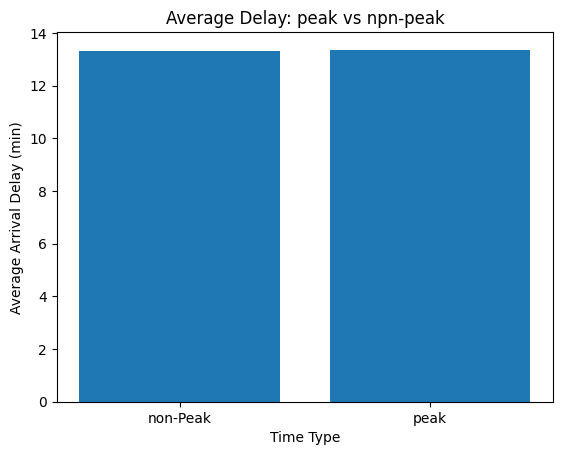

In [470]:
avg_delay = df.groupby('peak_hour')['actual_arrival_delay_min'].mean()
plt.bar(['non-Peak', 'peak'], avg_delay)
plt.xlabel('Time Type')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay: peak vs npn-peak')
plt.show()

In [471]:
df['traffic_level'] = pd.cut(df['traffic_congestion_index'],
                                       bins=[0, 20, 40, 60, 80, 100],
                                       labels=['low', 'medium', 'high', 'very_high', 'extreme'])

In [472]:
df['traffic_level'].head()

0      extreme
1         high
2    very_high
3      extreme
4         high
Name: traffic_level, dtype: category
Categories (5, str): ['low' < 'medium' < 'high' < 'very_high' < 'extreme']

In [473]:
avg_delay = df.groupby('traffic_level')['actual_arrival_delay_min'].mean()

<BarContainer object of 5 artists>

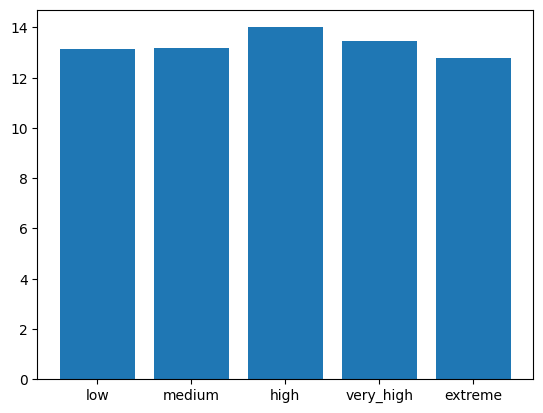

In [474]:
plt.bar(avg_delay.index, avg_delay.values) 

In [475]:
weather_delay = df.groupby('weather_condition')['actual_arrival_delay_min'].mean()

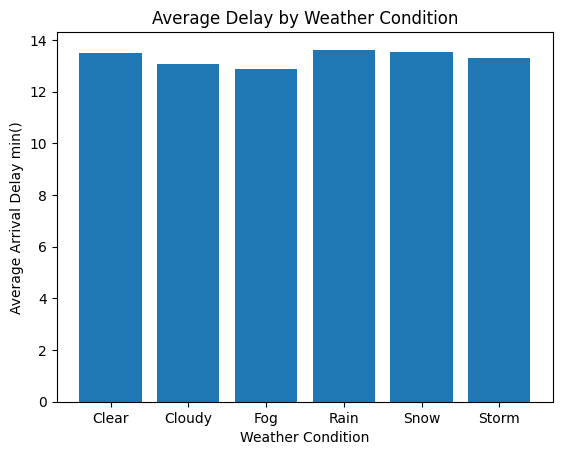

In [476]:
plt.bar(weather_delay.index, weather_delay.values)
plt.title('Average Delay by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Arrival Delay min()')
plt.show()

In [477]:
event_analysis = df.groupby('event_type')['actual_arrival_delay_min'].mean()
event_analysis

event_type
Concert     12.832512
Festival    12.769231
NO Event    13.526002
Parade      13.619048
Protest     13.895349
Sports      12.820755
Name: actual_arrival_delay_min, dtype: float64

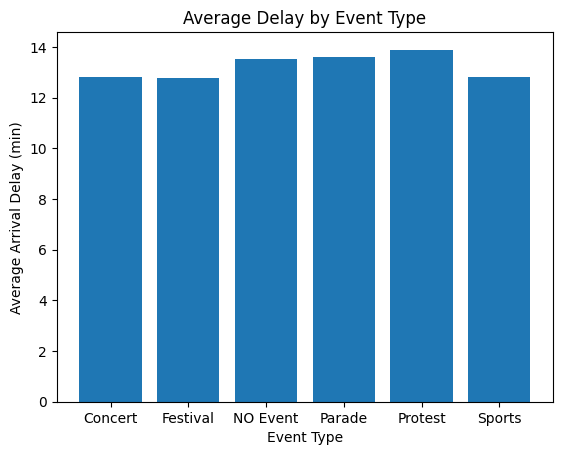

In [478]:
plt.bar(event_analysis.index, event_analysis.values)
plt.xlabel('Event Type')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay by Event Type')
plt.show()

In [479]:
df['event_attendance_est'].unique()

array([  500,     0, 50000,  2000, 10000])

In [480]:
df['attendas_level'] = df['event_attendance_est'].replace({
    0: 'no_event',
    500: 'small',
    2000: 'medium',
    10000: 'large',
    50000: 'huge'
})

In [481]:
attendance_analysis = df.groupby('attendas_level')['actual_arrival_delay_min'].mean()
attendance_analysis

attendas_level
huge        14.204762
large       13.754098
medium      14.404762
no_event    12.990132
small       12.790055
Name: actual_arrival_delay_min, dtype: float64

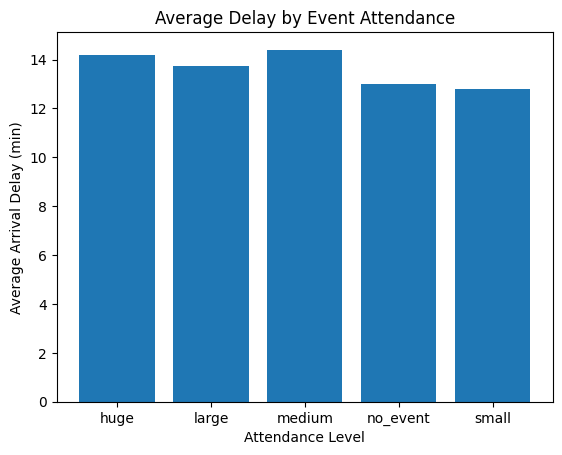

In [482]:

plt.bar(attendance_analysis.index, attendance_analysis.values)
plt.xlabel('Attendance Level')
plt.ylabel('Average Arrival Delay (min)')
plt.title('Average Delay by Event Attendance')
plt.show()

In [483]:
pd.to_datetime(df['time'])
df

C:\Users\praka\AppData\Local\Temp\ipykernel_24832\1317857667.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df['time'])


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,traffic_level,attendas_level
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,NO Event,500,81,0,peak,6,Winter,0,extreme,small
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,NO Event,0,53,0,non-Peak,6,Autumn,1,high,no_event
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,Sports,0,67,1,non-Peak,6,Autumn,0,very_high,no_event
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,NO Event,500,84,0,non-Peak,6,Winter,1,extreme,small
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,NO Event,500,46,0,non-Peak,6,Spring,1,high,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,T01995,2023-01-21,23:45:00,Bus,Route_11,Station_46,Station_39,23:46:00,00:11:00,15,...,NO Event,0,96,0,non-Peak,5,Winter,1,extreme,no_event
1996,T01996,2023-01-22,00:00:00,Train,Route_9,Station_44,Station_42,00:03:00,00:41:00,11,...,Festival,0,12,0,peak,6,Winter,1,low,no_event
1997,T01997,2023-01-22,00:15:00,Bus,Route_12,Station_4,Station_45,00:18:00,00:35:00,1,...,NO Event,0,24,1,non-Peak,6,Summer,1,medium,no_event
1998,T01998,2023-01-22,00:30:00,Tram,Route_17,Station_29,Station_48,00:34:00,01:18:00,7,...,NO Event,2000,23,0,non-Peak,6,Summer,1,medium,medium


In [484]:
df = df.drop(columns=['trip_id', 'route_id', 'origin_station', 'destination_station'])

In [485]:
df

,date,time,transport_type,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,...,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,traffic_level,attendas_level
0,2023-01-01,05:00:00,Tram,05:02:00,05:55:00,12,3,Storm,5.1,52,...,NO Event,500,81,0,peak,6,Winter,0,extreme,small
1,2023-01-01,05:15:00,Metro,05:16:00,05:55:00,15,9,Rain,34.0,64,...,NO Event,0,53,0,non-Peak,6,Autumn,1,high,no_event
2,2023-01-01,05:30:00,Bus,05:33:00,06:17:00,0,0,Clear,29.5,35,...,Sports,0,67,1,non-Peak,6,Autumn,0,very_high,no_event
3,2023-01-01,05:45:00,Tram,05:49:00,06:08:00,15,10,Clear,27.4,55,...,NO Event,500,84,0,non-Peak,6,Winter,1,extreme,small
4,2023-01-01,06:00:00,Tram,06:00:00,06:35:00,-1,14,Snow,0.1,90,...,NO Event,500,46,0,non-Peak,6,Spring,1,high,small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2023-01-21,23:45:00,Bus,23:46:00,00:11:00,15,14,Storm,17.2,98,...,NO Event,0,96,0,non-Peak,5,Winter,1,extreme,no_event
1996,2023-01-22,00:00:00,Train,00:03:00,00:41:00,11,25,Snow,0.0,89,...,Festival,0,12,0,peak,6,Winter,1,low,no_event
1997,2023-01-22,00:15:00,Bus,00:18:00,00:35:00,1,21,Snow,12.9,95,...,NO Event,0,24,1,non-Peak,6,Summer,1,medium,no_event
1998,2023-01-22,00:30:00,Tram,00:34:00,01:18:00,7,9,Clear,17.8,55,...,NO Event,2000,23,0,non-Peak,6,Summer,1,medium,medium


In [486]:
df['weather_condition'].unique()

<StringArray>
['Storm', 'Rain', 'Clear', 'Snow', 'Fog', 'Cloudy']
Length: 6, dtype: str

In [487]:
df['season'].unique()

<StringArray>
['Winter', 'Autumn', 'Spring', 'Summer']
Length: 4, dtype: str

In [488]:
df['event_type'].unique()

<StringArray>
['NO Event', 'Sports', 'Protest', 'Parade', 'Concert', 'Festival']
Length: 6, dtype: str

In [489]:
df = pd.get_dummies(df, columns=['weather_condition', 'season', 'event_type', 'transport_type'])

In [490]:
df

,date,time,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,...,event_type_Concert,event_type_Festival,event_type_NO Event,event_type_Parade,event_type_Protest,event_type_Sports,transport_type_Bus,transport_type_Metro,transport_type_Train,transport_type_Tram
0,2023-01-01,05:00:00,05:02:00,05:55:00,12,3,5.1,52,46,13.0,...,False,False,True,False,False,False,False,False,False,True
1,2023-01-01,05:15:00,05:16:00,05:55:00,15,9,34.0,64,11,11.4,...,False,False,True,False,False,False,False,True,False,False
2,2023-01-01,05:30:00,05:33:00,06:17:00,0,0,29.5,35,31,14.1,...,False,False,False,False,False,True,True,False,False,False
3,2023-01-01,05:45:00,05:49:00,06:08:00,15,10,27.4,55,41,6.4,...,False,False,True,False,False,False,False,False,False,True
4,2023-01-01,06:00:00,06:00:00,06:35:00,-1,14,0.1,90,30,18.5,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2023-01-21,23:45:00,23:46:00,00:11:00,15,14,17.2,98,35,4.6,...,False,False,True,False,False,False,True,False,False,False
1996,2023-01-22,00:00:00,00:03:00,00:41:00,11,25,0.0,89,44,15.4,...,False,True,False,False,False,False,False,False,True,False
1997,2023-01-22,00:15:00,00:18:00,00:35:00,1,21,12.9,95,32,2.7,...,False,False,True,False,False,False,True,False,False,False
1998,2023-01-22,00:30:00,00:34:00,01:18:00,7,9,17.8,55,35,8.8,...,False,False,True,False,False,False,False,False,False,True


In [491]:
df = df.dropna(subset=['traffic_level'])

In [492]:
df['peak_hour'] = df['peak_hour'].replace({'non-Peak': 0, 'peak': 1})

In [493]:
df['peak_hour'].head()

0    1
1    0
2    0
3    0
4    0
Name: peak_hour, dtype: object

In [494]:
df['attendas_level'] = df['attendas_level'].replace({'no_event': 0, 'small': 1, 'medium': 2, 'large': 3, 'huge': 4})

In [495]:
df.isnull().sum()

date                          0
time                          0
scheduled_departure           0
scheduled_arrival             0
actual_departure_delay_min    0
actual_arrival_delay_min      0
temperature_C                 0
humidity_percent              0
wind_speed_kmh                0
precipitation_mm              0
event_attendance_est          0
traffic_congestion_index      0
holiday                       0
peak_hour                     0
weekday                       0
delayed                       0
traffic_level                 0
attendas_level                0
weather_condition_Clear       0
weather_condition_Cloudy      0
weather_condition_Fog         0
weather_condition_Rain        0
weather_condition_Snow        0
weather_condition_Storm       0
season_Autumn                 0
season_Spring                 0
season_Summer                 0
season_Winter                 0
event_type_Concert            0
event_type_Festival           0
event_type_NO Event           0
event_ty

In [496]:
df['traffic_level'].unique()

['extreme', 'high', 'very_high', 'medium', 'low']
Categories (5, str): ['low' < 'medium' < 'high' < 'very_high' < 'extreme']

In [497]:
df['traffic_level'] = df['traffic_level'].astype(str)

In [498]:
df['traffic_level'] =  df['traffic_level'].replace({'extreme': 5, 'high': 4, 'very_high': 3, 'medium': 2, 'low': 1})

In [499]:
df['traffic_level'] = df['traffic_level'].astype(int)

In [500]:
df['traffic_level'].head()

0    5
1    4
2    3
3    5
4    4
Name: traffic_level, dtype: int64

In [501]:
df['attendas_level'].head()

0    1
1    0
2    0
3    1
4    1
Name: attendas_level, dtype: object

In [502]:
df['attendas_level'] = df['attendas_level'].astype(int)

In [503]:
len(df)

1981

In [504]:
X = df.drop(['actual_departure_delay_min', 'actual_arrival_delay_min', 'date', 'time', 'scheduled_departure', 'scheduled_arrival'], axis=1)
y = df['actual_departure_delay_min']

In [505]:
X.columns

Index(['temperature_C', 'humidity_percent', 'wind_speed_kmh',
       'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index',
       'holiday', 'peak_hour', 'weekday', 'delayed', 'traffic_level',
       'attendas_level', 'weather_condition_Clear', 'weather_condition_Cloudy',
       'weather_condition_Fog', 'weather_condition_Rain',
       'weather_condition_Snow', 'weather_condition_Storm', 'season_Autumn',
       'season_Spring', 'season_Summer', 'season_Winter', 'event_type_Concert',
       'event_type_Festival', 'event_type_NO Event', 'event_type_Parade',
       'event_type_Protest', 'event_type_Sports', 'transport_type_Bus',
       'transport_type_Metro', 'transport_type_Train', 'transport_type_Tram'],
      dtype='str')

In [506]:
y

0       12
1       15
2        0
3       15
4       -1
        ..
1995    15
1996    11
1997     1
1998     7
1999     0
Name: actual_departure_delay_min, Length: 1981, dtype: int64

In [507]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [436]:
X.dtypes

temperature_C               float64
humidity_percent              int64
wind_speed_kmh                int64
precipitation_mm            float64
event_attendance_est          int64
traffic_congestion_index      int64
holiday                       int64
peak_hour                    object
weekday                       int64
delayed                       int64
traffic_level                 int64
attendas_level                int64
weather_condition_Clear        bool
weather_condition_Cloudy       bool
weather_condition_Fog          bool
weather_condition_Rain         bool
weather_condition_Snow         bool
weather_condition_Storm        bool
season_Autumn                  bool
season_Spring                  bool
season_Summer                  bool
season_Winter                  bool
event_type_Concert             bool
event_type_Festival            bool
event_type_NO Event            bool
event_type_Parade              bool
event_type_Protest             bool
event_type_Sports           

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.trans

In [437]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [438]:
y_pred = lr.predict(X_test)

In [439]:
print(y_pred)

[ 8.22208891  7.70158978  9.06173723  9.28517132  9.60482399  8.48831153
  8.18764743  9.22508344  8.79485904  7.68001226  7.74098473  8.25197257
  7.35333663  7.50158689  9.52712848  8.79965103  8.16906139  8.70272155
  8.5721622   7.45253551  8.10632957  8.21660216  8.19198403  7.66947543
  9.10863804 10.5681293   7.54346196  8.99382529  9.50877655  7.6660769
  9.27487042  8.16618541  8.1292831   7.20196589  8.46761558  8.48932734
  9.78470598  9.30818083 10.01836672 10.18445691  9.44563365  8.49906476
  8.44327194  9.08877157  7.14151413  6.66464571  9.1003133   8.88154239
  8.54004222  7.39639706 10.05104459  9.75579199  7.9832262   8.06732099
  8.16310233  9.29316125  8.7852351   8.31180844  9.95339902  8.26399388
  6.8263647   7.50246998  9.0347841   7.27531277  8.98155033 10.12555838
  9.11437275  9.85938378  7.90229054  8.89971737  9.63736824  8.89690877
  9.05684505  9.25377024  7.51080578  9.55762949  8.4386276   8.38108295
  9.98909188  7.66832524  9.39109434  9.19585103  7.

In [440]:
mae = mean_absolute_error(y_test, y_pred)

In [441]:
print('MAE:', mae)

MAE: 5.541722248236963


In [442]:
mse = mean_squared_error(y_test, y_pred)

In [443]:
print('MSE:', mse)

MSE: 40.803743682023075


In [444]:
r2 = r2_score(y_test, y_pred)

In [445]:
print('R2 Score:', r2)

R2 Score: -0.02021528590927213


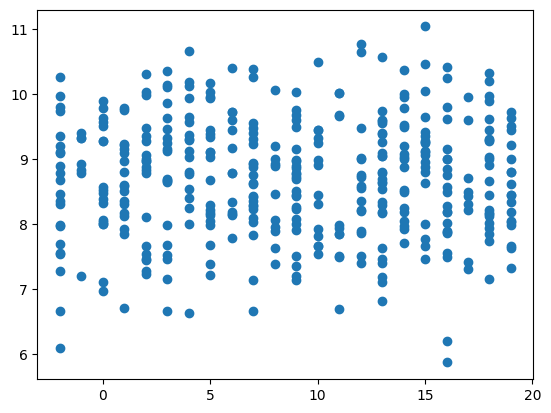

In [446]:
plt.scatter(y_test, y_pred)

In [424]:
print(len(y_test))
print(len(y_pred))

397
397


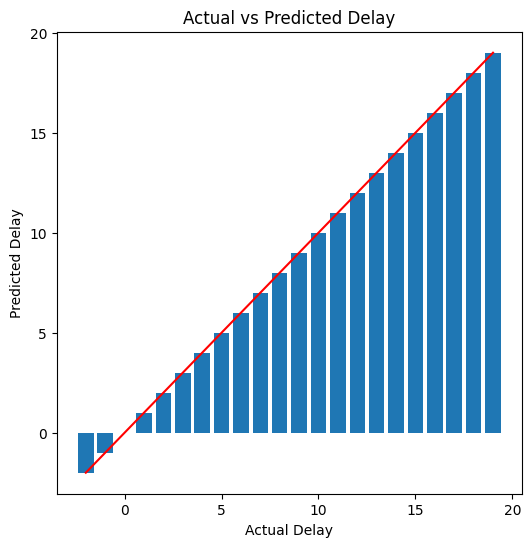

In [425]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.bar(y_test, y_pred)

plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red')

plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Actual vs Predicted Delay")

plt.show()

In [426]:
y_test = y_test.reset_index(drop=True)

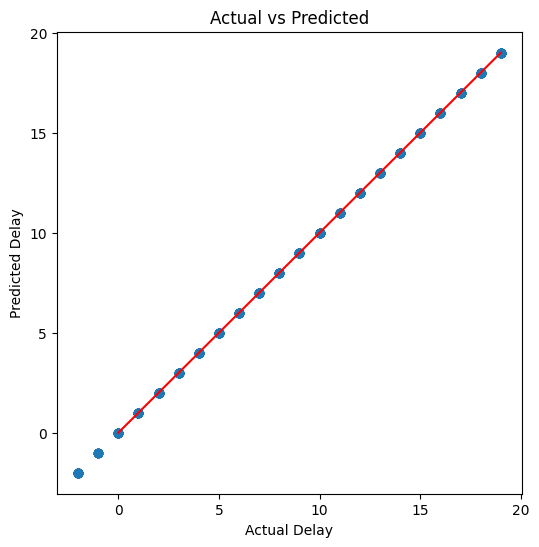

In [427]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot([0, max(y_test)],
         [0, max(y_test)],
         color='red')

plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Actual vs Predicted")

plt.show()

In [428]:
print(y_test[:5])
print(y_pred[:5])

0    17
1    -2
2     2
3     0
4     6
Name: actual_departure_delay_min, dtype: int64
[ 1.7000000e+01 -2.0000000e+00  2.0000000e+00 -1.1581807e-12
  6.0000000e+00]
